# Wafer process suspicion simulation

This notebook runs the Polars-native wafer-level good_bad vs. context-y scoring simulation using step_seq as the process key and root_lot_id + wafer_id as the wafer identity, then displays the ranked cases visually inline.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import display

from wafer_process_suspicion_sim import (
    DISPLAY_COLUMNS,
    ScoreParams,
    SINGLE_STEP_LOT_OUTPUT_COLUMNS,
    score_single_step_lot_dataframe,
    _run_multi_lot_sanity_checks,
    _run_sanity_checks,
    make_multi_lot_simulation_dataframe,
    make_simulation_dataframe,
    plot_ranked_cases,
    score_process_dataframe,
)

## Single-step, multi-lot scoring template

Use a Polars DataFrame or LazyFrame when the user provides one step_seq with one or more root lots. Required columns are root_lot_id, wafer_id, good_bad, and y. All lots are pooled and scored once for the step, and the returned value is a one-row Polars DataFrame. wafer_id may repeat across different root_lot_id values, while each (root_lot_id, wafer_id) pair must be unique. Pass step_seq separately if it is not already a column.

In [2]:
user_df = pl.DataFrame(
    {
        "root_lot_id": ["LOT_A"] * 5 + ["LOT_B"] * 5,
        "wafer_id": [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
        "good_bad": ["bad", "bad", "good", "good", "good", "bad", "good", "good", "good", "good"],
        "y": [1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    }
)

single_result_df = score_single_step_lot_dataframe(
    user_df,
    step_seq="ETCH_010",
)

display(single_result_df.select(SINGLE_STEP_LOT_OUTPUT_COLUMNS))


step_seq,root_lot_count,root_lot_ids,input_rows,N_real,N_eff,B_eff,m_eff,n_B1,n_B0,n_G1,n_G0,quality_real,p_tail_eff,evidence_eff,r_real,score
str,i64,list[str],i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""ETCH_010""",2,"[""LOT_A"", ""LOT_B""]",10,10,13,3,3,3,0,0,7,1.0,0.003497,5.655992,0.666667,3.770661


In [3]:
params = ScoreParams()
sim_df = make_simulation_dataframe()
result_df = score_process_dataframe(sim_df, params=params)
_run_sanity_checks(result_df)

print("Sanity checks passed.")

Sanity checks passed.


In [4]:
display(result_df.select(DISPLAY_COLUMNS))

step_seq,root_lot_count,root_lot_ids,input_rows,N_real,n_B_real,n_G_real,m_real,N_eff,B_eff,m_eff,virtual_good_h,n_B1,n_B0,n_G1,n_G0,mean_likelihood,quality_real,p_tail_eff,evidence_eff,r_real,score,score_exact_alt
str,i64,list[str],i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""lot_perfect_N25""",1,"[""LOT01""]",25,25,5,20,5,28,5,5,3,5,0,0,20,0.827974,1.0,0.00001,11.495576,0.833333,9.579647,3.932781
"""medium_perfect_N10""",1,"[""LOT01""]",10,10,2,8,2,13,2,2,3,2,0,0,8,0.827974,1.0,0.012821,4.356709,0.666667,2.904473,1.25849
"""noisy_good_in_y1_N25""",1,"[""LOT01""]",25,25,5,20,13,28,5,13,3,5,0,8,12,0.531322,0.80107,0.013095,4.335507,0.833333,2.894203,2.714221
"""no_good_N5""",1,"[""LOT01""]",5,5,5,0,5,8,5,5,3,5,0,0,0,0.95,1.0,0.017857,4.025352,0.5,2.012676,0.128233
"""tiny_perfect_N2""",1,"[""LOT01""]",2,2,1,1,1,5,1,1,3,1,0,0,1,0.87178,1.0,0.2,1.609438,0.285714,0.459839,0.078411
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""bad_missed_N25""",1,"[""LOT01""]",25,25,5,20,1,28,5,1,3,1,4,0,20,0.516911,0.192264,0.178571,1.722767,0.833333,0.276022,2.3853
"""random_mix_N25""",1,"[""LOT01""]",25,25,5,20,6,28,5,6,3,2,3,4,16,0.46584,0.259872,0.28547,1.253618,0.833333,0.271483,1.799512
"""tiny_single_bad_N1""",1,"[""LOT01""]",1,1,1,0,1,4,1,1,3,1,0,0,0,0.95,1.0,0.25,1.386294,0.166667,0.231049,0.008549


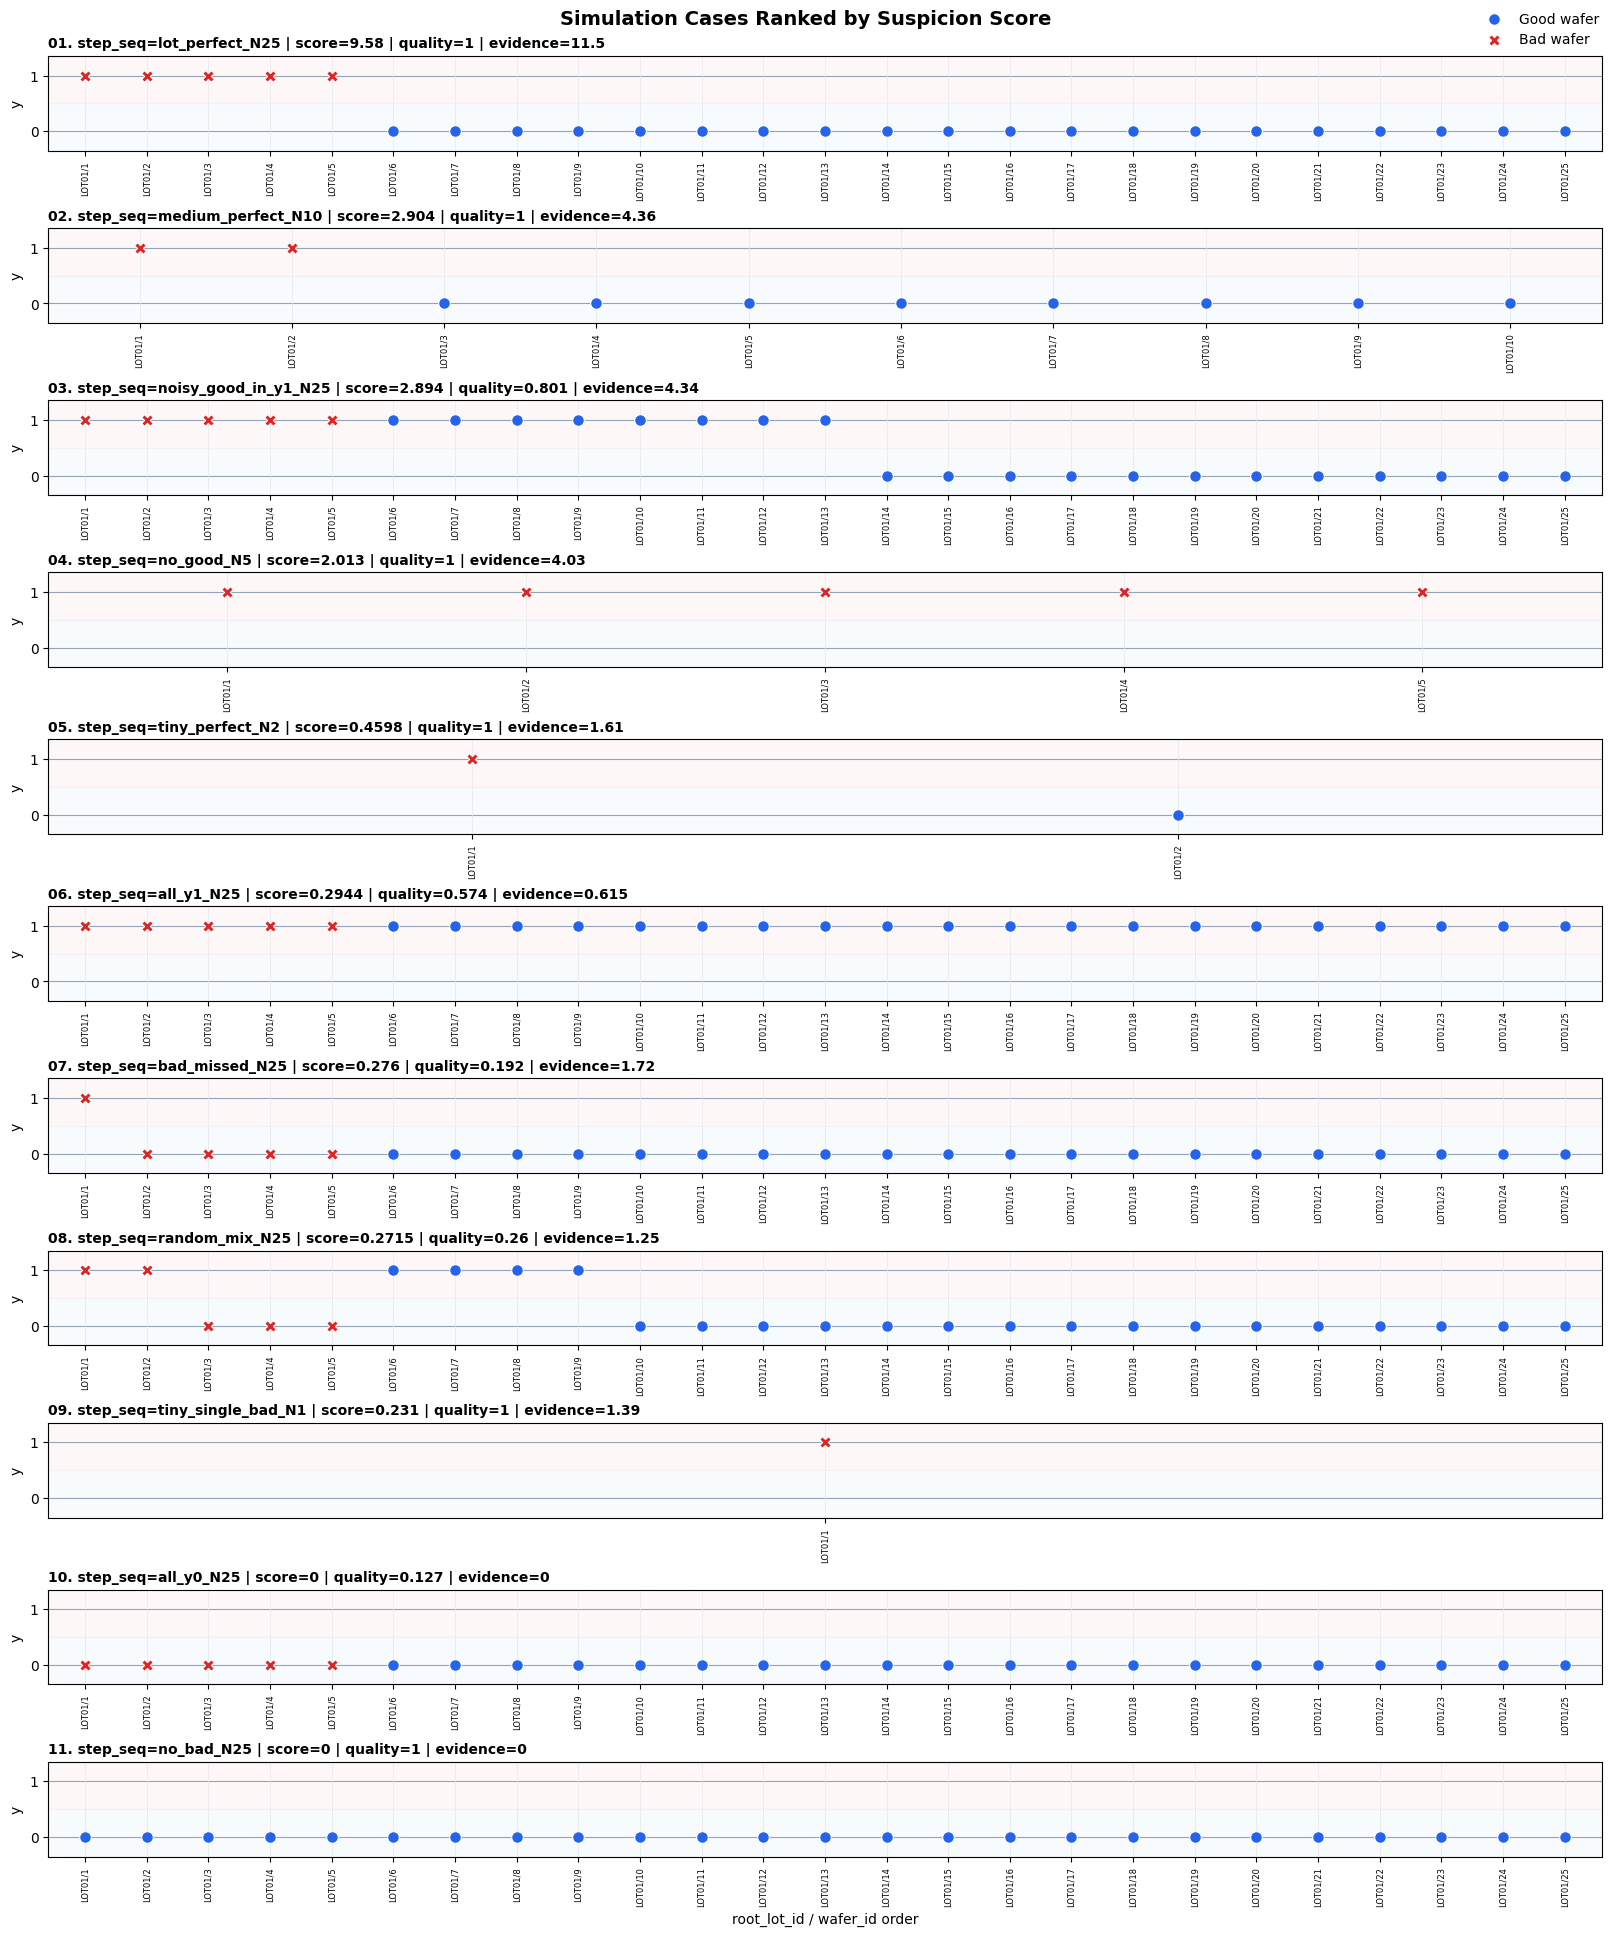

In [5]:
fig = plot_ranked_cases(sim_df, result_df)
plt.show()

## Three-lot simulation

The original single-lot cases remain above. Each case below contains LOT_A, LOT_B, and LOT_C, with wafer_id restarting from 1 inside each lot. All three lots are pooled into one score per step_seq.

In [6]:
multi_lot_sim_df = make_multi_lot_simulation_dataframe()
multi_lot_result_df = score_process_dataframe(multi_lot_sim_df, params=params)
_run_multi_lot_sanity_checks(multi_lot_result_df)

print("Three-lot sanity checks passed.")

Three-lot sanity checks passed.


In [7]:
display(multi_lot_result_df.select(DISPLAY_COLUMNS))

step_seq,root_lot_count,root_lot_ids,input_rows,N_real,n_B_real,n_G_real,m_real,N_eff,B_eff,m_eff,virtual_good_h,n_B1,n_B0,n_G1,n_G0,mean_likelihood,quality_real,p_tail_eff,evidence_eff,r_real,score,score_exact_alt
str,i64,list[str],i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""three_lot_perfect""",3,"[""LOT_A"", ""LOT_B"", ""LOT_C""]",24,24,6,18,6,27,6,6,3,6,0,0,18,0.835119,1.0,0.000003,12.598149,0.827586,10.426054,3.578767
"""three_lot_good_noise""",3,"[""LOT_A"", ""LOT_B"", ""LOT_C""]",24,24,6,18,9,27,6,9,3,6,0,3,15,0.702249,0.911722,0.000284,8.167332,0.827586,6.162488,1.342165
"""three_lot_bad_missed""",3,"[""LOT_A"", ""LOT_B"", ""LOT_C""]",24,24,6,18,4,27,6,4,3,4,2,0,18,0.65341,0.503065,0.000855,7.064759,0.827586,2.941269,3.124626
"""three_lot_random_mix""",3,"[""LOT_A"", ""LOT_B"", ""LOT_C""]",24,24,6,18,7,27,6,7,3,3,3,4,14,0.458734,0.315442,0.158701,1.840735,0.827586,0.480534,2.005151


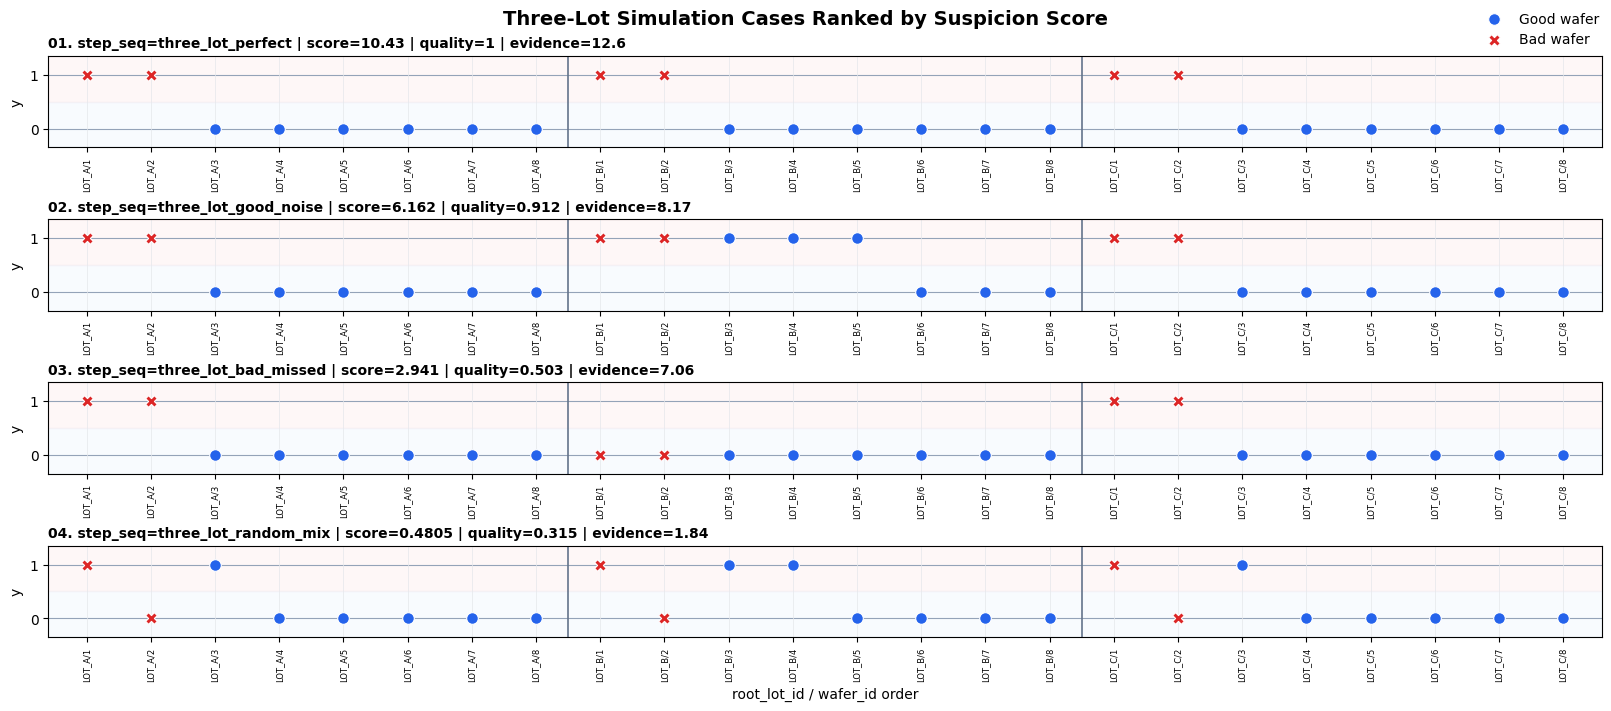

In [8]:
multi_lot_fig = plot_ranked_cases(
    multi_lot_sim_df,
    multi_lot_result_df,
    title="Three-Lot Simulation Cases Ranked by Suspicion Score",
)
plt.show()